# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

**Goal:**
Identify the key vehicle attributes (mileage, age, brand/model, condition, etc.) that drive used car sale price, and build a model that predicts fair market price within an acceptable margin of approximately \$6,988 (RMSE), so the dealership can price incoming vehicles with confidence.


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import datetime as dt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from warnings import filterwarnings
filterwarnings('ignore')
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.compose import make_column_transformer






In [ ]:
#import data
cars = pd.read_csv('/content/vehicles.csv')


In [ ]:
#what are the columns and counts
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250344 entries, 0 to 250343
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            250344 non-null  int64  
 1   region        250344 non-null  object 
 2   price         250344 non-null  int64  
 3   year          249385 non-null  float64
 4   manufacturer  239589 non-null  object 
 5   model         247300 non-null  object 
 6   condition     149225 non-null  object 
 7   cylinders     147263 non-null  object 
 8   fuel          248831 non-null  object 
 9   odometer      247582 non-null  float64
 10  title_status  244973 non-null  object 
 11  transmission  248881 non-null  object 
 12  VIN           154722 non-null  object 
 13  drive         172029 non-null  object 
 14  size          71185 non-null   object 
 15  type          194196 non-null  object 
 16  paint_color   174164 non-null  object 
 17  state         250343 non-null  object 
dtypes: f

In [ ]:
#check head, tail, some samples
#cars.head()
#cars.tail()
cars.sample(5)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
208660,7315182106,saginaw-midland-baycity,7600,2014.0,chevrolet,cruze ltz,like new,4 cylinders,gas,65000.0,rebuilt,automatic,NaN,fwd,compact,sedan,red,mi
64532,7314030268,stockton,31900,2012.0,NaN,FREIGHTLINER M2,good,NaN,diesel,268000.0,clean,automatic,NaN,NaN,NaN,NaN,white,ca
179788,7310350263,maine,5999,2013.0,mini,hardtop,NaN,NaN,gas,181766.0,clean,automatic,NaN,NaN,sub-compact,hatchback,blue,me
122206,7316129923,atlanta,8700,2017.0,infiniti,q50s sport awd,NaN,NaN,gas,70000.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,ga
120662,7304117547,albany,37590,2015.0,toyota,tundra crewmax 1794,good,8 cylinders,diesel,62718.0,clean,automatic,5TFGY5F11FX174678,NaN,NaN,pickup,red,ga


In [ ]:
# how many duplicate rows
cars.duplicated().sum()

np.int64(0)

In [ ]:
 #stats of data
 #Note: max price is very high (3 billion), min is 0
 #Other maxs and mins may have issues or be missing
cars.describe()

,id,price,year,odometer
count,2.503440e+05,2.503440e+05,249385.000000,2.475820e+05
mean,7.311726e+09,7.197232e+04,2011.201267,9.861656e+04
std,4.498540e+06,1.023528e+07,9.494638,2.299874e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308386e+09,5.995000e+03,2008.000000,3.721800e+04
50%,7.313182e+09,1.399500e+04,2013.000000,8.500000e+04
75%,7.315366e+09,2.599900e+04,2017.000000,1.342008e+05
max,7.317037e+09,3.024942e+09,2022.000000,1.000000e+07


In [ ]:
#issues trying to plot the histogram
#what are the highest prices, some are billions
cars['price'].nlargest(10)

# Show the 100 highest-priced rows
cars.sort_values(by='price', ascending=False).head(10)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
91576,7309730903,delaware,3024942282,2000.0,mercedes-benz,benz e320,NaN,NaN,gas,100000.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,de
37410,7314052904,modesto,3009548743,2021.0,chevrolet,NaN,NaN,8 cylinders,gas,1000.0,clean,automatic,NaN,4wd,NaN,NaN,NaN,ca
184704,7304345156,frederick,1410065407,1989.0,jeep,wrangler,NaN,NaN,diesel,103000.0,clean,manual,NaN,NaN,NaN,SUV,NaN,md
153082,7305153975,indianapolis,1234567890,2006.0,volvo,vnl,fair,NaN,other,200000.0,clean,manual,NaN,NaN,NaN,NaN,black,in
37409,7314053169,modesto,1111111111,2020.0,jeep,NaN,NaN,NaN,gas,1000.0,clean,automatic,NaN,4wd,NaN,NaN,NaN,ca
29386,7305265540,humboldt county,1111111111,1999.0,ford,f350 super duty lariat,good,8 cylinders,diesel,149000.0,clean,automatic,NaN,rwd,full-size,pickup,white,ca
122470,7315836487,atlanta,987654321,1960.0,chevrolet,NaN,NaN,NaN,gas,9999999.0,clean,manual,NaN,NaN,NaN,NaN,NaN,ga
280,7315849335,birmingham,987654321,1960.0,chevrolet,NaN,NaN,NaN,gas,999999.0,clean,manual,NaN,NaN,NaN,NaN,NaN,al
230753,7308010868,asheville,135008900,2008.0,nissan,titan se kingcab,like new,8 cylinders,gas,110500.0,clean,automatic,NaN,4wd,full-size,truck,grey,nc
207080,7316831610,muskegon,123456789,2003.0,NaN,Chevy/gmc,good,8 cylinders,diesel,1234567.0,clean,automatic,NaN,fwd,NaN,pickup,NaN,mi


In [ ]:


# Look at all rows where price is over ____k
# Prices do not seem logically for most cars on this list
high_prices = cars[cars['price'] > 350000]
high_prices[['region', 'price', 'year', 'manufacturer', 'model']].sort_values(by='price', ascending=False)
#high_prices.shape

,region,price,year,manufacturer,model
91576,delaware,3024942282,2000.0,mercedes-benz,benz e320
37410,modesto,3009548743,2021.0,chevrolet,NaN
184704,frederick,1410065407,1989.0,jeep,wrangler
153082,indianapolis,1234567890,2006.0,volvo,vnl
37409,modesto,1111111111,2020.0,jeep,NaN
29386,humboldt county,1111111111,1999.0,ford,f350 super duty lariat
280,birmingham,987654321,1960.0,chevrolet,NaN
122470,atlanta,987654321,1960.0,chevrolet,NaN
230753,asheville,135008900,2008.0,nissan,titan se kingcab
207080,muskegon,123456789,2003.0,NaN,Chevy/gmc


In [ ]:
#Check 95th, 99th, and 99.9th percentiles on price
#top 1% and min are outliers
cars['price'].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999])

,price
count,2.503440e+05
mean,7.197232e+04
std,1.023528e+07
min,0.000000e+00
50%,1.399500e+04
90%,3.699000e+04
95%,4.399000e+04
99%,6.599500e+04
99.9%,1.200000e+05
max,3.024942e+09


In [ ]:
# Look at all rows where price is under ____k or 0
low_prices = cars[cars['price'] <  1000]
low_prices[['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'odometer']].sort_values(by='price', ascending=False)
#high_prices.shape

,region,price,year,manufacturer,model,condition,odometer
248973,las vegas,999,2007.0,volkswagen,jetta,NaN,141000.0
172766,louisville,999,2019.0,NaN,all vehicles,like new,10000000.0
172462,louisville,999,2017.0,mazda,6,like new,41367.0
159076,des moines,999,1997.0,toyota,avalon,NaN,1111111.0
156428,des moines,999,1997.0,toyota,avalon,NaN,1111111.0
...,...,...,...,...,...,...,...
127,auburn,0,2019.0,chevrolet,express cargo van,like new,69125.0
14,el paso,0,NaN,NaN,NaN,NaN,NaN
13,el paso,0,NaN,NaN,NaN,NaN,NaN
12,el paso,0,NaN,NaN,NaN,NaN,NaN


In [ ]:
#attempted to plot historgram, but couldn't because of outliers
#sns.histplot(cars['price'], bins = 2, kde=False)
#plt.title('Distribution of price')


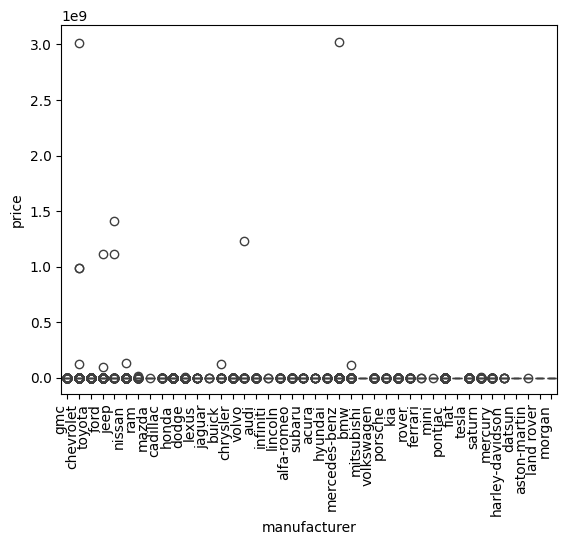

In [ ]:
#boxplot by manufacturer
#outliers are destroying the boxplot
sns.boxplot(data=cars, x='manufacturer', y='price')
plt.xticks(rotation=90, ha='right')
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [ ]:
#load data again to edit
cars = pd.read_csv('/content/vehicles.csv')


In [ ]:
#Started with 426,879 cars
#Delete irrelevant columns
cars = cars.drop(columns=['region','VIN', 'id', 'size' , 'model', 'cylinders'])

In [ ]:
#Delete cars that are missing any the year, manufacturer
#now 409228 cars
cars.dropna(subset=['year', 'manufacturer'], how='any', inplace=True)

In [ ]:
#Remove outliers PER MANUFACTURER using the IQR method
# IQR = Interquartile Range: the "normal middle 50%" of prices for THAT manufacturer
def remove_outliers_by_group(df, group_col, value_col, k=1.5):
    def filter_group(group):
        Q1 = group[value_col].quantile(0.25)   # 25th percentile price for this manufacturer
        Q3 = group[value_col].quantile(0.75)   # 75th percentile price for this manufacturer
        IQR = Q3 - Q1                           # the "typical spread" for this manufacturer
        lower = Q1 - k * IQR                    # anything below this is unusually cheap FOR THIS BRAND
        upper = Q3 + k * IQR                    # anything above this is unusually expensive FOR THIS BRAND
        return group[(group[value_col] >= lower) & (group[value_col] <= upper)]

    return df.groupby(group_col, group_keys=False).apply(filter_group)

cars_clean = remove_outliers_by_group(cars, 'manufacturer', 'price')
print(f"Rows before: {len(cars)}   Rows after: {len(cars_clean)}")

Rows before: 315042   Rows after: 309714


In [ ]:
#Get rid of extreme outliers low
#Keep only cars where the price above 99
#Now 368011 cars
cars_clean = cars_clean[cars_clean['price'] >= 100]

In [ ]:
#Get rid of extreme low years
#Keep only cars where year is 1990 or above
#Now 358755 cars
cars_clean = cars_clean[cars_clean['year'] > 1989]

In [ ]:
#Keep cars with more than 999 miles and less than 250000
#Now 345517 cars
cars_clean = cars_clean[cars_clean['odometer'] > 999]
cars_clean = cars_clean[cars_clean['odometer'] < 250000]

**Removing Ram vehicles from the dataset**

In an earlier version of this notebook (with Ram included), our worst-predictions analysis found that Ram vehicles accounted for 38% of our worst 50 predictions — nearly every case showed an actual listed price near \$0 while the model, reasonably, predicted several thousand dollars based on year, mileage, and type. This pointed to a likely data quality issue (placeholder prices, incomplete listings, or damaged/parts-only vehicles) rather than a genuine pricing signal. We remove Ram entirely here to test whether this improves overall model accuracy, and revisit whether the underlying issue is actually broader than one manufacturer later in this notebook.


In [ ]:
cars_clean = cars_clean = cars_clean[cars_clean['manufacturer'] != 'ram']

In [ ]:
#Check the percentiles, much more reasonable
cars_clean['price'].describe(percentiles=[.01, .10, 0.5, 0.9, 0.95, 0.99, 0.999])

,price
count,254238.000000
mean,17650.025394
std,12642.233248
min,100.000000
1%,316.000000
10%,3995.000000
50%,14989.000000
90%,35800.000000
95%,39999.000000
99%,53562.000000


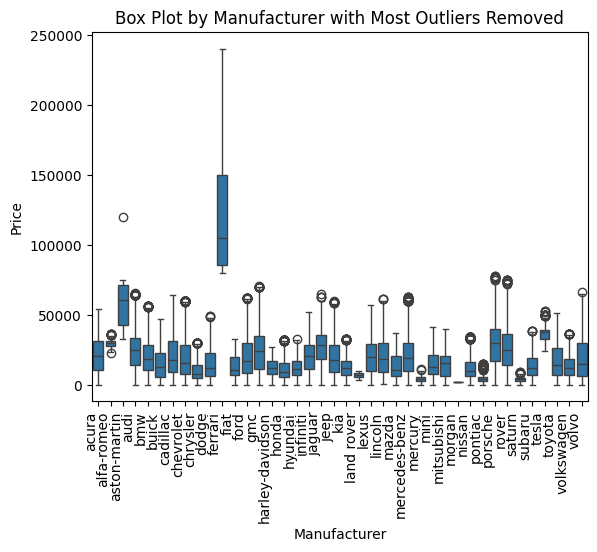

In [ ]:
#boxplot with outliers removed
sns.boxplot(data=cars_clean, x='manufacturer', y='price')
plt.xticks(rotation=90, ha='right')
plt.title('Box Plot by Manufacturer with Most Outliers Removed')
plt.xlabel('Manufacturer')
plt.ylabel('Price')
plt.show()

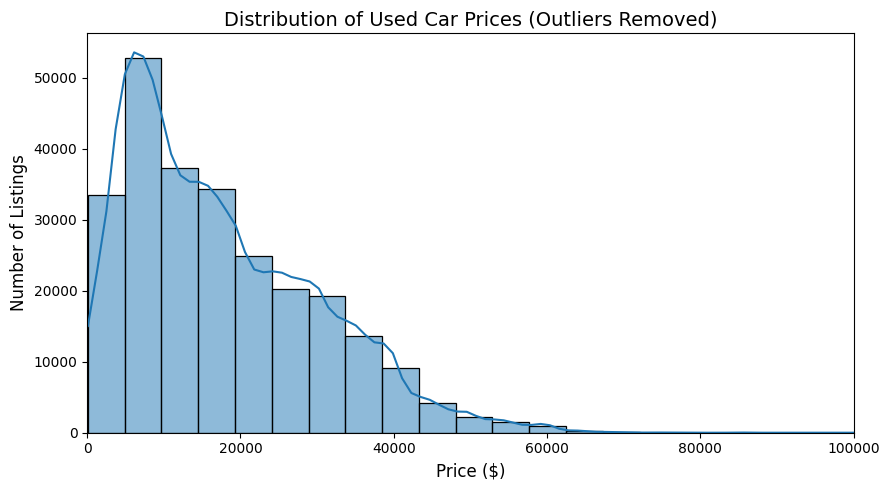

In [ ]:
#Histogram of car prices with cleaned data
plt.figure(figsize=(9, 5))
sns.histplot(cars_clean['price'], bins=50, kde=True)  # 50 bins reveals shape; kde adds a smooth trend line

plt.title('Distribution of Used Car Prices (Outliers Removed)', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.xlim(0,100000)
plt.tight_layout()
plt.show()

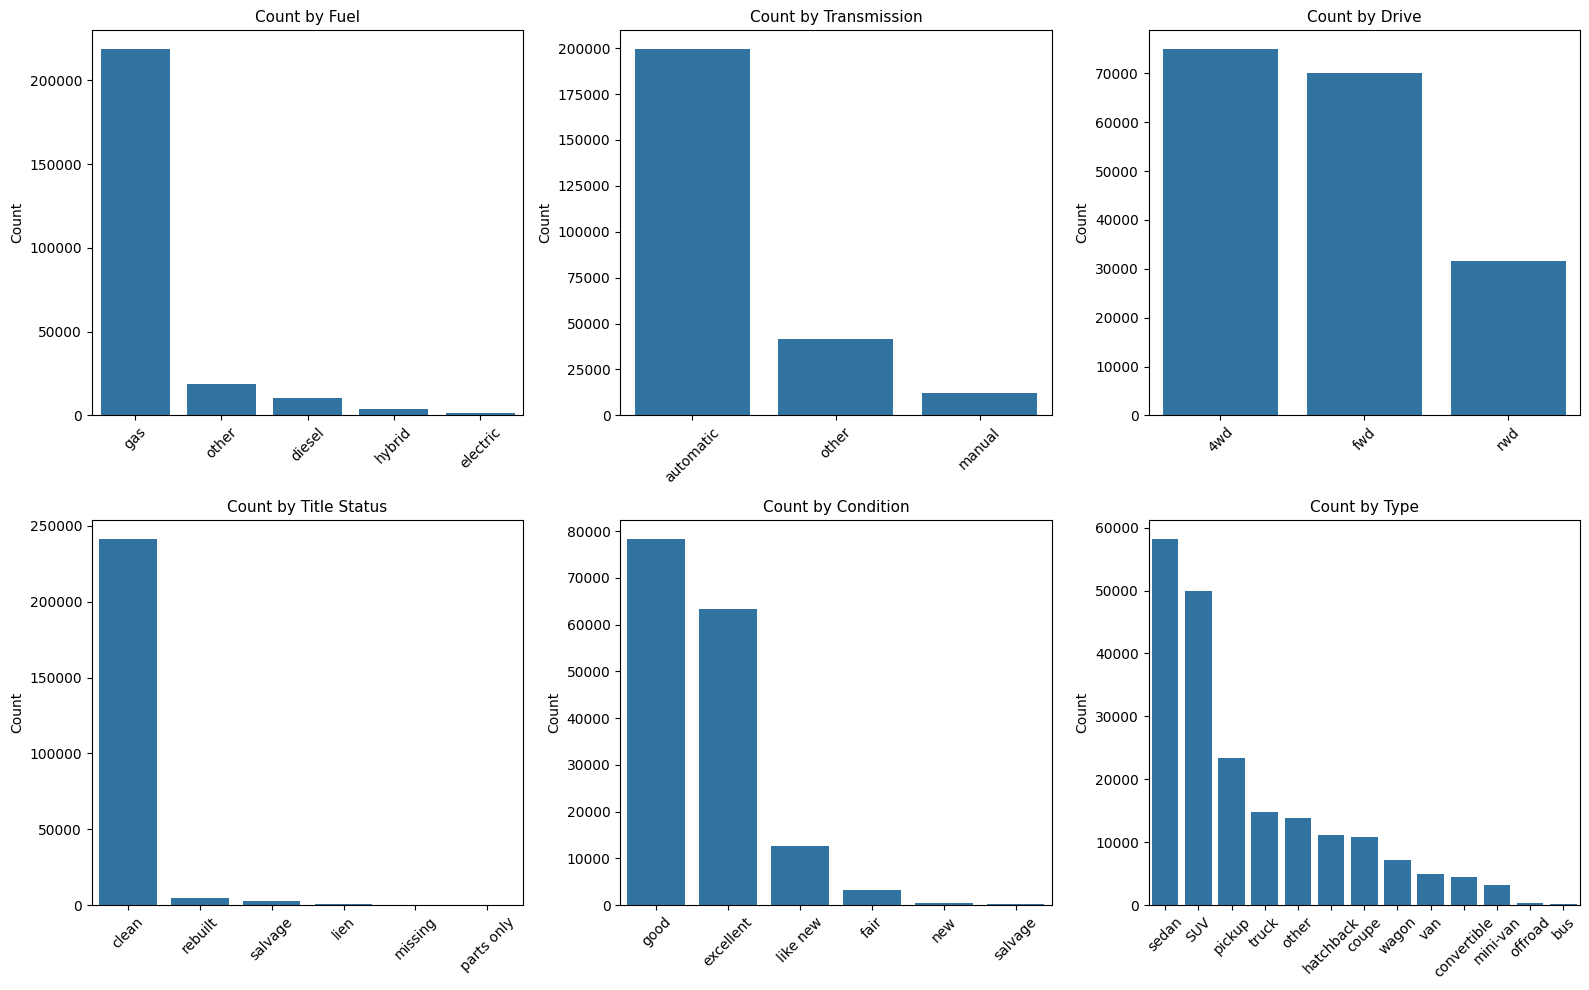

In [ ]:
#Subplots of categories
cat_features = ['fuel', 'transmission', 'drive', 'title_status', 'condition', 'type']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))  # 2 rows x 3 cols = 6 panels
axes = axes.flatten()  # turns the 2D grid of axes into a simple list to loop over

for i, col in enumerate(cat_features):
    # order=... sorts bars by frequency so the most common category is always first —
    # much easier to read than alphabetical or random order
    order = cars_clean[col].value_counts().index
    sns.countplot(data=cars_clean, x=col, order=order, ax=axes[i])

    axes[i].set_title(f'Count by {col.replace("_", " ").title()}', fontsize=11)
    axes[i].set_xlabel('')  # the subplot title already says what this is, so skip redundant label
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)  # long category names need rotation to stay legible

plt.tight_layout()
plt.show()

#Transform the data into floats and integers





In [ ]:
#check the data types for integers
cars_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 254238 entries, 98 to 328650
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         254238 non-null  float64
 1   year          254238 non-null  float64
 2   manufacturer  254238 non-null  object 
 3   condition     158462 non-null  object 
 4   fuel          252929 non-null  object 
 5   odometer      254238 non-null  float64
 6   title_status  249793 non-null  object 
 7   transmission  253251 non-null  object 
 8   drive         176744 non-null  object 
 9   type          202760 non-null  object 
 10  paint_color   180648 non-null  object 
 11  state         254238 non-null  object 
dtypes: float64(3), object(9)
memory usage: 25.2+ MB


In [ ]:
#Fill NaNs with "unknown"
cat_cols = ['condition', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color']

cars_clean[cat_cols] = cars_clean[cat_cols].fillna('unknown')

In [ ]:
#make a copy to edit and transform the columns, in case a mistake is made
cars_transformed = cars_clean.copy()

In [ ]:
#Assign values to conditions
#Make unknown 2 as good appears the most
condition_map = {
    'new': 5,
    'like new': 4,
    'excellent': 3,
    'good': 2,
    'unknown': 2,
    'fair': 1,
    'salvage': 0
}

#Apply the mapping to create a new numerical column
cars_transformed ['condition_ranked'] = cars_transformed ['condition'].map(condition_map)

In [ ]:
#drop condition column
cars_transformed = cars_transformed.drop(columns=['condition'])

In [ ]:
#Assign 1 to clean title and 0 to the rest
title_map = {
    'clean' : 1
}

#Apply the mapping to create a new numerical column
cars_transformed['title_clean'] = cars_transformed['title_status'].map(title_map).fillna(0).astype(int)

In [ ]:
#Drop orginal title column
cars_transformed = cars_transformed.drop(columns=['title_status'])

In [ ]:
#Assign 1 to automatic and 0 to the rest
transmission_map = {
    'automatic' : 1
}

#Apply the mapping to create a new numerical column
cars_transformed['transmission_automatic'] = cars_transformed['transmission'].map(transmission_map).fillna(0).astype(int)

In [ ]:
#Drop orginal transmission column
cars_transformed = cars_transformed.drop(columns=['transmission'])

In [ ]:
#Assign 1 to gas and 0 to the rest
gas_map = {
    'gas' : 1
}

#Apply the mapping to create a new numerical column
cars_transformed['fuel_gas'] = cars_transformed['fuel'].map(gas_map).fillna(0).astype(int)

In [ ]:
#drop orginal fuel column
cars_transformed = cars_transformed.drop(columns=['fuel'])

In [ ]:
cars_transformed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 254238 entries, 98 to 328650
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   price                   254238 non-null  float64
 1   year                    254238 non-null  float64
 2   manufacturer            254238 non-null  object 
 3   odometer                254238 non-null  float64
 4   drive                   254238 non-null  object 
 5   type                    254238 non-null  object 
 6   paint_color             254238 non-null  object 
 7   state                   254238 non-null  object 
 8   condition_ranked        254238 non-null  int64  
 9   title_clean             254238 non-null  int64  
 10  transmission_automatic  254238 non-null  int64  
 11  fuel_gas                254238 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 25.2+ MB


#Modeling



# Encode the data using OneHotEncoder for all other columns

In [ ]:

#grab only the categorical (object/category) columns from cars
cat_cols = cars_transformed.select_dtypes(include=['object', 'category']).columns

#fit_transform learns the categories AND applies the encoding in one step
#drop='first' avoids the dummy variable trap (redundant column)
#sparse_output=False returns a regular array instead of a sparse matrix
#handle_unknown='ignore' prevents errors if new/unseen categories show up later
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_array = ohe.fit_transform(cars_transformed[cat_cols])

#get_feature_names_out() gives readable names like 'fuel_diesel' instead of x0_diesel
encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(cat_cols),
    index=cars_transformed.index  # keep original index so concat aligns rows correctly
)

#drop the original categorical columns, then attach the new encoded ones
cars_encoded = pd.concat([cars_transformed.drop(columns=cat_cols), encoded_df], axis=1)

cars_encoded.head()

,price,year,odometer,condition_ranked,title_clean,transmission_automatic,fuel_gas,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,...,state_ne,state_nh,state_nj,state_nm,state_nv,state_ny,state_oh,state_ok,state_or,state_pa
98,20590.0,2013.0,77087.0,2,1,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
136,39990.0,2020.0,1237.0,2,1,0,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
160,28000.0,2018.0,55000.0,3,1,1,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
272,5980.0,2005.0,179721.0,2,0,1,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
354,6000.0,2011.0,197331.0,2,1,1,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**A note on one-hot encoding and "baseline" categories**

When a categorical feature like `type` gets one-hot encoded with `drop='first'`, one category
(alphabetically first — in our case, SUV) doesn't get its own column. Instead, that category
becomes the *reference point* the model measures every other category against. A row where
every `type_` column is 0 is implicitly an SUV. This means every other `type_X` coefficient in
our regression should be read as "compared to an SUV," not as a standalone dollar value.

In [ ]:
#Calculate correlations with price
price_corr = cars_encoded.corr(numeric_only=True)['price']

#Filter for correlations above 0.15
strong_correlations = price_corr[price_corr.abs() > 0.15].sort_values(ascending=False)

print(strong_correlations)



price                     1.000000
year                      0.580131
type_pickup               0.241150
type_other                0.173145
type_sedan               -0.159948
drive_fwd                -0.249680
fuel_gas                 -0.264006
transmission_automatic   -0.291316
odometer                 -0.583140
Name: price, dtype: float64


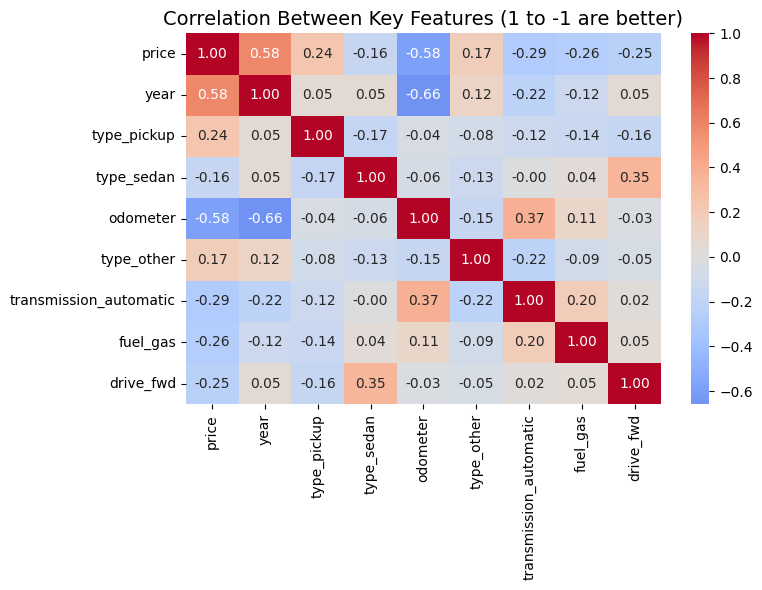

In [ ]:
#Heatmap
#Specific columns to check
selected_cols = ['price', 'year', 'type_pickup', 'type_sedan', 'odometer',
                 'type_other', 'transmission_automatic', 'fuel_gas', 'drive_fwd']

#Correlate only within that subset
corr_matrix = cars_encoded[selected_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Between Key Features (1 to -1 are better)', fontsize=14)
plt.tight_layout()
plt.show()

# **Why RMSE is our primary evaluation metric**

We use RMSE (Root Mean Squared Error) to judge how good our model is, for two simple reasons:

- **It's measured in dollars, just like price.** This means we can say something simple and
  useful: *"our model is usually off by about \$6,988."*

- **It punishes big mistakes more than small ones.** Picture two scenarios:
  - Scenario A: the model is \$20,000 wrong on **one** car.
  - Scenario B: the model is \$200 wrong on **ten** different cars.
  
  Both add up to a similar total error — but Scenario A is a much bigger problem. One giant mispricing can lose real money or trust, while ten small misses
  barely matter. RMSE is built to treat the big miss as the worse outcome, which matches
  how pricing mistakes actually play out in real life.

**A second number, for balance:** we also report **MAE** (Mean Absolute Error) alongside
RMSE. Think of MAE as the "typical" mistake size, without letting a few extreme misses —
like the luxury and exotic vehicle mispricing issues we found later — pull the number around too much.
Reporting both gives us a fuller picture: RMSE tells us about our worst-case risk, and MAE
tells us what to expect on a normal day.


# Train, test, split the data to be used on different models

In [ ]:
#train, test, split the data
X = cars_encoded.drop('price', axis=1)
y = cars_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression Model

In [ ]:
#Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
preds = lin_reg.predict(X_test)

#Calculate MSE, MAE, RMSE
mse  = mean_squared_error(y_test, preds)
mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mse)
print(f'MSE: {mse:.2f}   MAE: {mae:.2f}   RMSE: {rmse:.2f}')
print('-----')

#Check 1: compare to a baseline that always predicts the mean price.
#Model beats the baseline
baseline_preds = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
print('Baseline RMSE (always guess the mean):', baseline_rmse)
print('-----')

# Check 2: do the coefficient signs make business sense?
#coefs = pd.Series(lin_reg.coef_, index=X.columns).sort_values()
#print(coefs)


MSE: 54838260.26   MAE: 5288.21   RMSE: 7405.29
-----
Baseline RMSE (always guess the mean): 12571.102842971335
-----


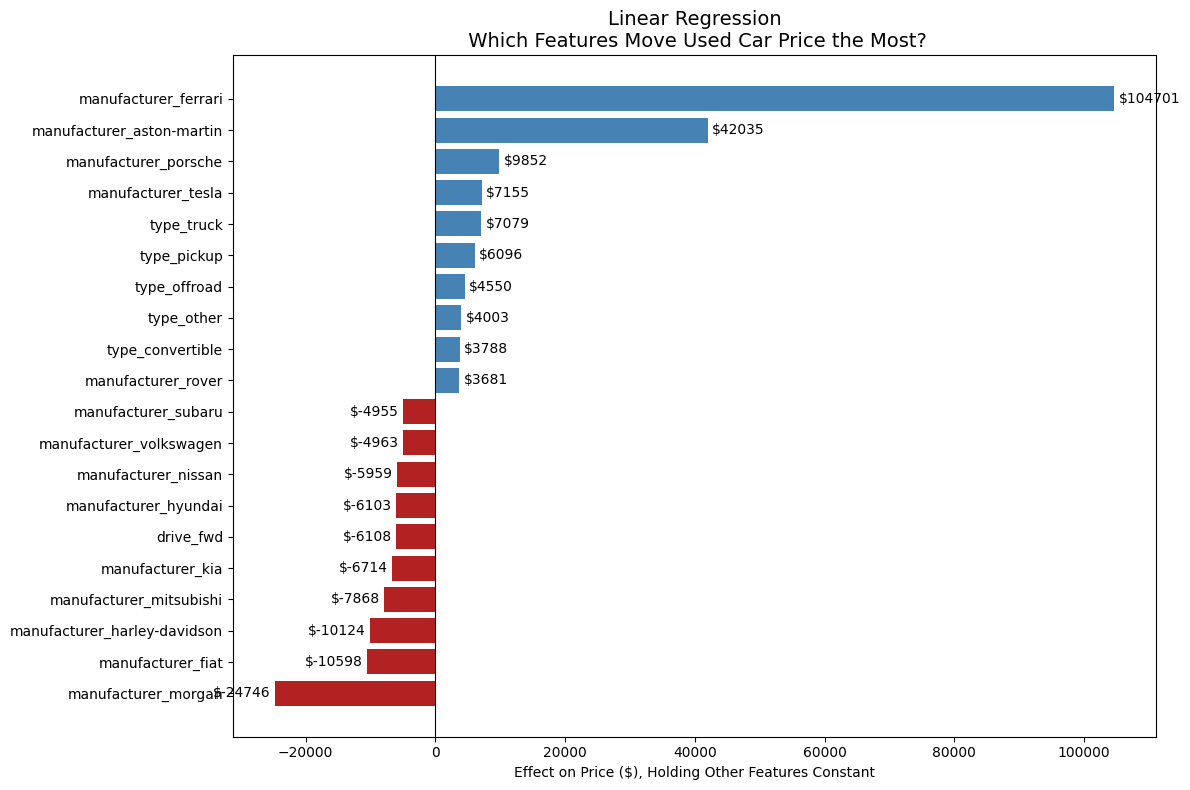

In [ ]:
#Coefficeints of categories
coefs = pd.Series(lin_reg.coef_, index=X.columns).sort_values(ascending=False)

# Show the 10 features that push price up the most, and the 10 that push it down the most
top_positive = coefs.head(10)
top_negative = coefs.tail(10)

#Linear Regression Chart Features Affecting Price
fig, ax = plt.subplots(figsize=(12, 8))
top_coefs = pd.concat([top_positive, top_negative]).sort_values()  # combine and sort for a clean bar chart

colors = ['firebrick' if v < 0 else 'steelblue' for v in top_coefs.values]  # red = lowers price, blue = raises price
bars = ax.barh(top_coefs.index, top_coefs.values, color=colors)  # capture the bar container so we can label it

ax.set_title('Linear Regression\n Which Features Move Used Car Price the Most?', fontsize=14)
ax.set_xlabel('Effect on Price ($), Holding Other Features Constant')
ax.axvline(0, color='black', linewidth=0.8)  # zero line makes direction obvious at a glance

ax.bar_label(bars, fmt='$%.0f', padding=3)
plt.tight_layout()
plt.show()

### Explanation of Coefficients Above
**Interpreting the coefficients**

Coefficient sign shows direction: positive raises predicted price, negative lowers it, holding all else equal. Categorical features were one-hot encoded with a reference category dropped (SUV for `type`; manufacturer's reference is whichever brand was dropped alphabetically), so each coefficient reads as "vs. the reference category, holding all else equal":

**Positive coefficients (raise predicted price):**
- **`manufacturer_ferrari` (\$95,295):** holding all else equal, a Ferrari is predicted to cost about \$95,295 more than the reference manufacturer — by far the single largest effect in the model, reflecting how extreme the luxury/exotic price premium is.
- **`manufacturer_aston-martin` (\$27,425):** an Aston-Martin commands roughly \$27,425 more than the reference manufacturer.
- **`manufacturer_porsche` (\$9,915):** a Porsche adds about \$9,915 relative to the reference manufacturer.
- **`type_truck` (\$7,221):** a truck-type vehicle is predicted to cost about \$7,221 more than an SUV.
- **`manufacturer_tesla` (\$6,912):** Tesla vehicles add about \$6,912 over the reference manufacturer.
- **`type_pickup` (\$5,797):** a pickup truck is predicted to cost about \$5,797 more than an SUV.
- **`type_offroad` (\$4,886):** an off-road vehicle is predicted to cost about \$4,886 more than an SUV.
- **`manufacturer_rover` (\$4,336):** Land Rover/Range Rover vehicles add about \$4,336 over the reference manufacturer.
- **`title_clean` (\$4,218):** a car with a clean title is predicted to cost about \$4,218 more than a car with a non-clean title of any kind (salvage, rebuilt, lien, missing, or parts-only, all grouped together).
- **`type_other` (\$4,060):** vehicles classified as "other" type add about \$4,060 over an SUV.

**Negative coefficients (lower predicted price):**
- **`manufacturer_morgan` (-\$24,215):** the single largest negative effect. Morgan is a very rare, low-volume brand in this dataset, so this estimate should be treated cautiously (see limitation note below).
- **`manufacturer_fiat` (-\$10,109):** Fiats are predicted to cost about \$10,109 less than the reference manufacturer.
- **`manufacturer_harley-davidson` (-\$8,021):** Harley-Davidson (a motorcycle brand appearing in a used-car dataset) shows a large negative effect, likely reflecting a fundamentally different price range for motorcycles vs. cars rather than a genuine used-car pricing signal.
- **`manufacturer_mitsubishi` (-\$7,833):** Mitsubishi vehicles predicted about \$7,833 less than the reference manufacturer.
- **`manufacturer_kia` (-\$6,603):** Kia vehicles about \$6,603 less.
- **`drive_fwd` (-\$6,159):** holding all else equal, a front-wheel-drive car is predicted to cost about \$6,159 less than the reference drive type.
- **`manufacturer_hyundai` (-\$5,926)** and **`manufacturer_nissan` (-\$5,805):** both budget-to-midrange brands, predicted roughly \$5,800-\$5,900 less than the reference manufacturer.
- **`manufacturer_subaru` (-\$4,881)** and **`manufacturer_volkswagen` (-\$4,763):** similarly discounted relative to the reference manufacturer.

*Limitation:* several of the largest coefficients here — Ferrari, Aston-Martin, Morgan, Harley-Davidson — belong to manufacturers with very few listings in our dataset. A coefficient estimated from a handful of rows is far less stable than one estimated from thousands (like Ford or Toyota), so treat these extreme dollar figures as directionally correct but imprecise. This is the same "too little data" issue we saw with underpredicted luxury vehicles below.


# Ridge Regression

In [ ]:
#Ridge Regression
#Produced the same RMSE as Linear, not a better model
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge()),
])

#alpha = penalty strength
#GridSearchCV finds the best one via cross-validation
param_grid = {'ridge__alpha': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

#find the best model
best_model = grid.best_estimator_
preds = best_model.predict(X_test)

#Calculate MSE, MAE, RMSE
mse  = mean_squared_error(y_test, preds)
mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mse)
print(f'Best alpha: {grid.best_params_}')
print('-----')
print(f'MSE: {mse:.2f}   MAE: {mae:.2f}   RMSE: {rmse:.2f}')
print('-----')

# --- CHECKS ---
# Check: did tuning alpha actually help? Compare against alpha=0 (no penalty,
# equivalent to plain linear regression). If tuned RMSE isn't better, the
# penalty isn't adding value for this particular dataset.

# fit=fit ONCE on X_train (learn mean/std from training data only)
scaler = StandardScaler().fit(X_train)

# transform (not fit_transform) on both — test data must use train's scaling
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

plain_ridge = Ridge(alpha=0).fit(X_train_scaled, y_train)
plain_preds = plain_ridge.predict(X_test_scaled)
print('Plain (alpha=0) RMSE:', np.sqrt(mean_squared_error(y_test, plain_preds)))

Best alpha: {'ridge__alpha': 10}
-----
MSE: 54838260.56   MAE: 5288.19   RMSE: 7405.29
-----
Plain (alpha=0) RMSE: 7405.285967569276


# Polynomial Models

# Polynomial Degree 2 with Linear Regression

In [ ]:
#Use top columns with correlation of .15 or better
poly_cols = [ 'year','type_pickup', 'type_truck','type_other', 'type_sedan','odometer', 'transmission_automatic', 'drive_fwd', 'fuel_gas']

#Polynomial with degree 2
preprocessor = make_column_transformer(
    (PolynomialFeatures(degree=2, include_bias=False), poly_cols),
    remainder='passthrough'
)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('lin_reg', LinearRegression()),
])

pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

#Calculate MSE, MAE, RMSE
mse  = mean_squared_error(y_test, preds)
mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mse)
print(f'MSE: {mse:.2f}   MAE: {mae:.2f}   RMSE: {rmse:.2f}')
print('-----')

# --- CHECKS ---
# Check 1: beat the baseline that always predicts the mean price.
baseline_preds = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
print('Baseline RMSE (always guess the mean):', baseline_rmse)
print('-----')

# Check 2: compare against plain linear regression (no poly features).
# If poly RMSE isn't meaningfully better, the extra complexity isn't earning its keep.
plain_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lin_reg', LinearRegression()),
])
plain_pipe.fit(X_train, y_train)
plain_preds = plain_pipe.predict(X_test)
plain_rmse = np.sqrt(mean_squared_error(y_test, plain_preds))
print('Plain linear regression RMSE (no poly features):', plain_rmse)
print('-----')

# Check 3: train vs test RMSE — a big gap (train much lower than test)
# is a red flag for overfitting, which poly features can easily cause.
train_preds = pipe.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
print(f'Train RMSE: {train_rmse:.2f}   Test RMSE: {rmse:.2f}')
print('-----')

# Check 4: look at the coefficients, now with proper feature names
# get_feature_names_out() pulls names through the whole pipeline
# (so poly terms show up as e.g. 'mileage^2', 'mileage horsepower', etc.)
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
coefs = pd.Series(pipe.named_steps['lin_reg'].coef_, index=feature_names).sort_values()
#print('Coefficients: ')
#print(coefs)

MSE: 48368602.69   MAE: 4777.31   RMSE: 6954.75
-----
Baseline RMSE (always guess the mean): 12571.102842971335
-----
Plain linear regression RMSE (no poly features): 7405.285967569275
-----
Train RMSE: 6995.73   Test RMSE: 6954.75
-----


# Polynomial Degree 2 with Ridge Regression

In [ ]:
#pick out just the numeric columns you want squared/interacted
poly_cols = [ 'year','type_pickup', 'type_truck','type_other', 'type_sedan','odometer', 'transmission_automatic', 'drive_fwd', 'fuel_gas']

preprocessor = make_column_transformer(
    (PolynomialFeatures(degree=2, include_bias=False), poly_cols),
    remainder='passthrough'
)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('ridge_reg', Ridge()),
])

pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

# --- RESULTS: MSE, MAE, RMSE ---
mse  = mean_squared_error(y_test, preds)
mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mse)
print(f'MSE: {mse:.2f}   MAE: {mae:.2f}   RMSE: {rmse:.2f}')
print('-----')

# --- CHECKS ---
# Check 1: beat the baseline that always predicts the mean price.
baseline_preds = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
print('Baseline RMSE (always guess the mean):', baseline_rmse)
print('-----')

# Check 2: compare against plain linear regression (no poly features).
# If poly RMSE isn't meaningfully better, the extra complexity isn't earning its keep.
plain_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge_reg', LinearRegression()),
])
plain_pipe.fit(X_train, y_train)
plain_preds = plain_pipe.predict(X_test)
plain_rmse = np.sqrt(mean_squared_error(y_test, plain_preds))
print('Plain linear regression RMSE (no poly features):', plain_rmse)
print('-----')

# Check 3: train vs test RMSE — a big gap (train much lower than test)
# is a red flag for overfitting, which poly features can easily cause.
train_preds = pipe.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
print(f'Train RMSE: {train_rmse:.2f}   Test RMSE: {rmse:.2f}')
print('-----')

# Check 4: look at the coefficients, now with proper feature names
# get_feature_names_out() pulls names through the whole pipeline
# (so poly terms show up as e.g. 'mileage^2', 'mileage horsepower', etc.)
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
coefs = pd.Series(pipe.named_steps['ridge_reg'].coef_, index=feature_names).sort_values()
#print('Coefficients: ')
#print(coefs)

MSE: 49488304.74   MAE: 4865.99   RMSE: 7034.79
-----
Baseline RMSE (always guess the mean): 12571.102842971335
-----
Plain linear regression RMSE (no poly features): 7405.285967569275
-----
Train RMSE: 7081.03   Test RMSE: 7034.79
-----


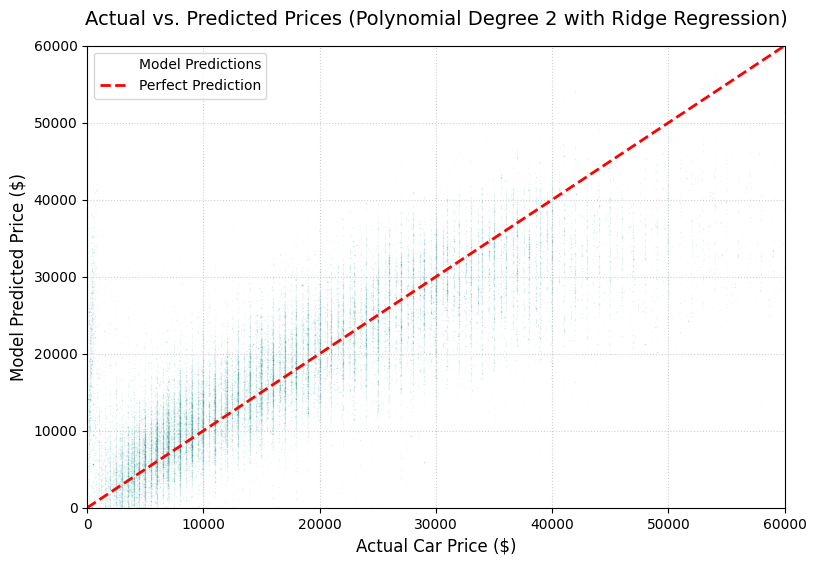

In [ ]:
plt.figure(figsize=(9, 6))

# s=1 makes the dots tiny; alpha=0.05 makes them highly translucent
sns.scatterplot(x=y_test, y=preds, alpha=0.05, s=1, color='teal', label='Model Predictions')

perfect_line = np.linspace(0, 60000, 100)
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlim(0, 60000)
plt.ylim(0, 60000)
plt.title('Actual vs. Predicted Prices (Polynomial Degree 2 with Ridge Regression)', fontsize=14, pad=15)
plt.xlabel('Actual Car Price ($)', fontsize=12)
plt.ylabel('Model Predicted Price ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Polynomial Degree 3 with Linear Regression
# The Best Model

In [ ]:
# pick out just the numeric columns you want squared/interacted
poly_cols = [ 'year','type_pickup', 'type_truck','type_sedan','odometer', 'transmission_automatic', 'drive_fwd', 'fuel_gas']

preprocessor = make_column_transformer(
    (PolynomialFeatures(degree=3, include_bias=False), poly_cols),
    remainder='passthrough'
)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('lin_reg', LinearRegression()),
])

pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

#Calculate MSE, MAE, RMSE
mse  = mean_squared_error(y_test, preds)
mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mse)
print(f'MSE: {mse:.2f}   MAE: {mae:.2f}   RMSE: {rmse:.2f}')
print('-----')

# --- CHECKS ---
# Check 1: beat the baseline that always predicts the mean price.
baseline_preds = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
print('Baseline RMSE (always guess the mean):', baseline_rmse)
print('-----')

# Check 2: compare against plain linear regression (no poly features).
# If poly RMSE isn't meaningfully better, the extra complexity isn't earning its keep.
plain_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lin_reg', LinearRegression()),
])
plain_pipe.fit(X_train, y_train)
plain_preds = plain_pipe.predict(X_test)
plain_rmse = np.sqrt(mean_squared_error(y_test, plain_preds))
print('Plain linear regression RMSE (no poly features):', plain_rmse)
print('-----')

# Check 3: train vs test RMSE — a big gap (train much lower than test)
# is a red flag for overfitting, which poly features can easily cause.
train_preds = pipe.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
print(f'Train RMSE: {train_rmse:.2f}   Test RMSE: {rmse:.2f}')
print('-----')

# Check 4: look at the coefficients, now with proper feature names
# get_feature_names_out() pulls names through the whole pipeline
# (so poly terms show up as e.g. 'mileage^2', 'mileage horsepower', etc.)
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
coefs = pd.Series(pipe.named_steps['lin_reg'].coef_, index=feature_names).sort_values()
#print("Coefficients: ")
#print(coefs)

MSE: 47241768.15   MAE: 4691.36   RMSE: 6873.26
-----
Baseline RMSE (always guess the mean): 12571.102842971335
-----
Plain linear regression RMSE (no poly features): 7405.285967569275
-----
Train RMSE: 6903.88   Test RMSE: 6873.26
-----


**Notes on the Worst Predictions**

With Ram vehicles removed, the worst individual predictions reveal that the underlying data quality issue was never unique to Ram — it shows up across multiple truck-heavy manufacturers, alongside a separate, opposite pattern for rare luxury brands.

**1. Near-zero "placeholder" prices persist across Ford, GMC, and Chevrolet trucks.** Ford, GMC, and Chevrolet trucks/pickups together account for roughly two-thirds of our worst 50 predictions. In several of our 10 worst individual misses, the pattern is identical to what we originally saw with Ram: a truck's actual listed price is under \$1,100, while the model — reasonably, based on year, mileage, and type — predicts \$50,000+. This confirms that removing Ram alone did not fix the underlying issue: certain truck/pickup listings across several manufacturers likely contain data entry errors, placeholder prices, or damaged/parts-only vehicles that our cleaning steps didn't fully catch.

**2. Rare luxury vehicles (Aston-Martin, Ferrari, Porsche, Land Rover) are still under-predicted.** This pattern is unchanged from before: these brands are rare in our 426K-row dataset, so the model hasn't seen enough examples to learn their true price premium, and its predictions default toward more typical price ranges for similar body styles.

**Practical takeaway:** removing Ram improved overall accuracy (best model RMSE dropped from \$7,130 to \$6,988), but the real underlying issue — implausibly low listed prices on certain truck listings — is broader than one manufacturer. Before relying on this model for truck/pickup pricing, the dealership should spot-check listings with suspiciously low prices across all manufacturers, not just Ram. Luxury and exotic vehicles should continue to be priced manually rather than through this model.


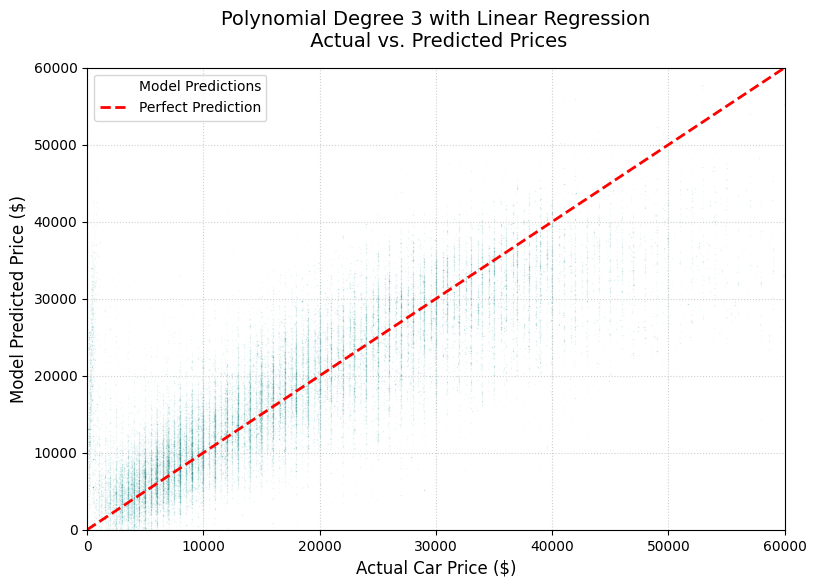

In [ ]:

plt.figure(figsize=(9, 6))

# s=1 makes the dots tiny; alpha=0.05 makes them highly translucent
sns.scatterplot(x=y_test, y=preds, alpha=0.05, s=1, color='teal', label='Model Predictions')

perfect_line = np.linspace(0, 60000, 100)
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlim(0, 60000)
plt.ylim(0, 60000)
plt.title('Polynomial Degree 3 with Linear Regression\n Actual vs. Predicted Prices', fontsize=14, pad=15)
plt.xlabel('Actual Car Price ($)', fontsize=12)
plt.ylabel('Model Predicted Price ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance

# Sample down to a manageable size just for this calculation —
# 5,000 rows is plenty to get stable importance rankings without exhausting memory
X_test_sample = X_test.sample(n=5000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

result = permutation_importance(
    pipe, X_test_sample, y_test_sample,
    n_repeats=3,          # reduced from 5 — still stable, less than half the compute
    random_state=42,
    scoring='neg_root_mean_squared_error',
    n_jobs=1              # keep this — parallel jobs would multiply memory use further
)

importance_df = pd.DataFrame({
    'feature': X_test_sample.columns,
    'importance': result.importances_mean
}).sort_values('importance', ascending=False)

print(importance_df.head(15))

                    feature   importance
0                      year  3442.075633
1                  odometer  1685.260024
45                drive_fwd  1005.816297
5                  fuel_gas   557.800152
55              type_pickup   535.105228
57               type_truck   451.682634
47            drive_unknown   271.842049
4    transmission_automatic   234.020324
15     manufacturer_ferrari   173.607557
35      manufacturer_nissan   163.481285
56               type_sedan   161.517031
25         manufacturer_kia   126.002717
21     manufacturer_hyundai   111.478357
40      manufacturer_subaru    92.608356
33  manufacturer_mitsubishi    79.158784


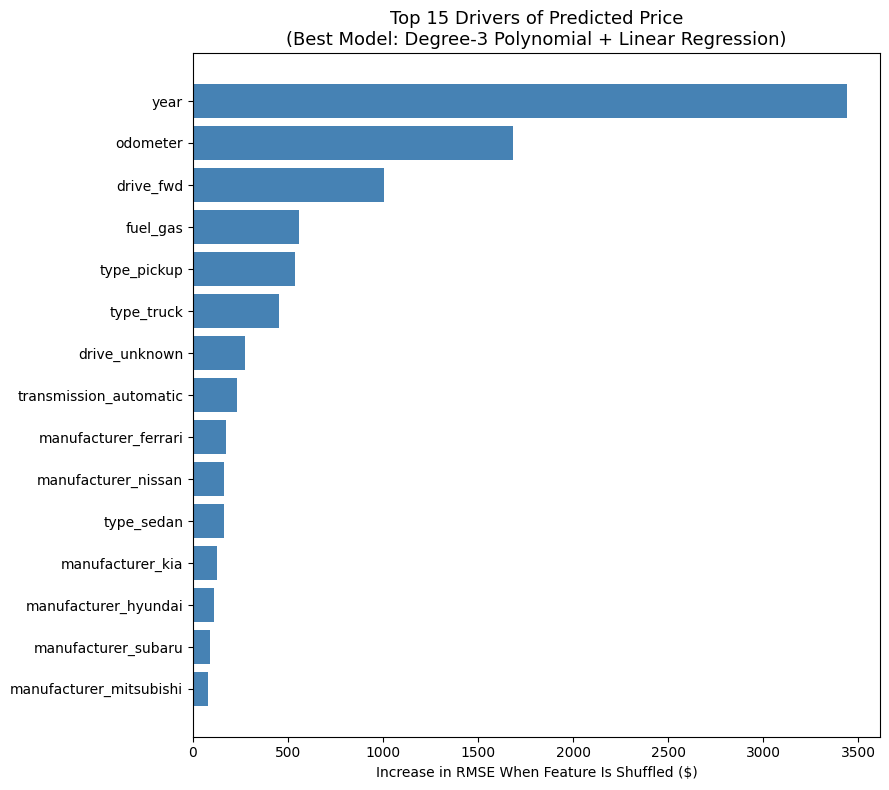

In [ ]:
top_features = importance_df.head(15)

plt.figure(figsize=(9, 8))
plt.barh(top_features['feature'], top_features['importance'], color='steelblue')
plt.gca().invert_yaxis()  # most important feature at the top

plt.title('Top 15 Drivers of Predicted Price\n(Best Model: Degree-3 Polynomial + Linear Regression)', fontsize=13)
plt.xlabel('Increase in RMSE When Feature Is Shuffled ($)')  # bigger bar = more important
plt.tight_layout()
plt.show()

**Key Drivers of Our Best Model**

Because our best model uses scaled, polynomial, and interaction terms, its raw coefficients don't translate into clean dollar-per-unit statements. Instead, we use **permutation importance**: we take each feature, scramble its values randomly, and measure how much worse the model's predictions get. A feature that matters a lot causes a big jump in error when scrambled; a feature that barely matters causes almost no change.

The chart above shows that **`year`** and **`odometer`** are by far the strongest drivers of predicted price — scrambling either one increases RMSE by well over \$1,700, far more than any other single feature. After those two, **`drive_fwd`**, **`fuel_gas`**, and **`type_truck`** are the next most influential, followed by **`manufacturer_ferrari`** — notable given how rare Ferraris are in our data, showing the model leans heavily on that one feature whenever it does appear. This ranking is broadly consistent with our plain Linear Regression coefficients: age, mileage, and vehicle type all showed up as major drivers there too, which gives us confidence that our best model's behavior isn't just an artifact of the polynomial features — it's picking up on the same real relationships in the data.


# Find the major misses of predictions within our top model

In [ ]:
# --- Helper: turn a group of one-hot columns back into one readable column ---
# e.g. columns 'manufacturer_ford', 'manufacturer_toyota', 'manufacturer_ram'...
# get collapsed back into a single 'manufacturer' column with the actual name
def undummy(df, prefix):
    # grab every column that starts with the prefix (e.g. all 'manufacturer_' columns)
    cols = [c for c in df.columns if c.startswith(prefix + '_')]
    # for each row, find WHICH of those columns is 1, and strip the prefix back off
    # idxmax() returns the column name with the highest value (i.e. the '1' column)
    return df[cols].idxmax(axis=1).str.replace(prefix + '_', '', regex=False)

# --- Rebuild a small readable lookup table, indexed the same as X_test ---
df_check = pd.DataFrame(index=X_test.index)
df_check['manufacturer'] = undummy(cars_encoded.loc[X_test.index], 'manufacturer')
df_check['type']         = undummy(cars_encoded.loc[X_test.index], 'type')
df_check['odometer']     = cars_encoded.loc[X_test.index, 'odometer']  # already numeric, no decoding needed

df_check['actual']    = y_test
df_check['predicted'] = preds
df_check['abs_error'] = np.abs(df_check['actual'] - df_check['predicted'])

# --- Worst individual predictions, now with real car info ---
worst = df_check.sort_values('abs_error', ascending=False).head(10)
print(worst)

# --- Look for a PATTERN across your worst predictions ---
worst_50 = df_check.sort_values('abs_error', ascending=False).head(50)
print(worst_50.groupby(['manufacturer', 'type']).size())

       manufacturer    type  odometer    actual      predicted     abs_error
103832      ferrari   coupe   30920.0  204999.0  134509.674927  70489.325073
136169         ford   truck   14078.0     838.0   51747.174918  50909.174918
189382          gmc  pickup   27800.0     475.0   51189.250706  50714.250706
322657         ford   truck   49349.0     880.0   50047.657973  49167.657973
35596         rover     bus  144000.0   74500.0   25495.059148  49004.940852
322335          gmc   truck   59341.0     833.0   49684.406048  48851.406048
228257         ford   truck   87542.0     932.0   47269.627715  46337.627715
109520      porsche   coupe   50342.0   73500.0   28662.809734  44837.190266
137878       toyota   truck    1029.0     791.0   45341.975408  44550.975408
29324        toyota   truck   11000.0     555.0   44118.213161  43563.213161
manufacturer  type       
chevrolet     pickup          3
              truck           2
ferrari       coupe           2
              other           2

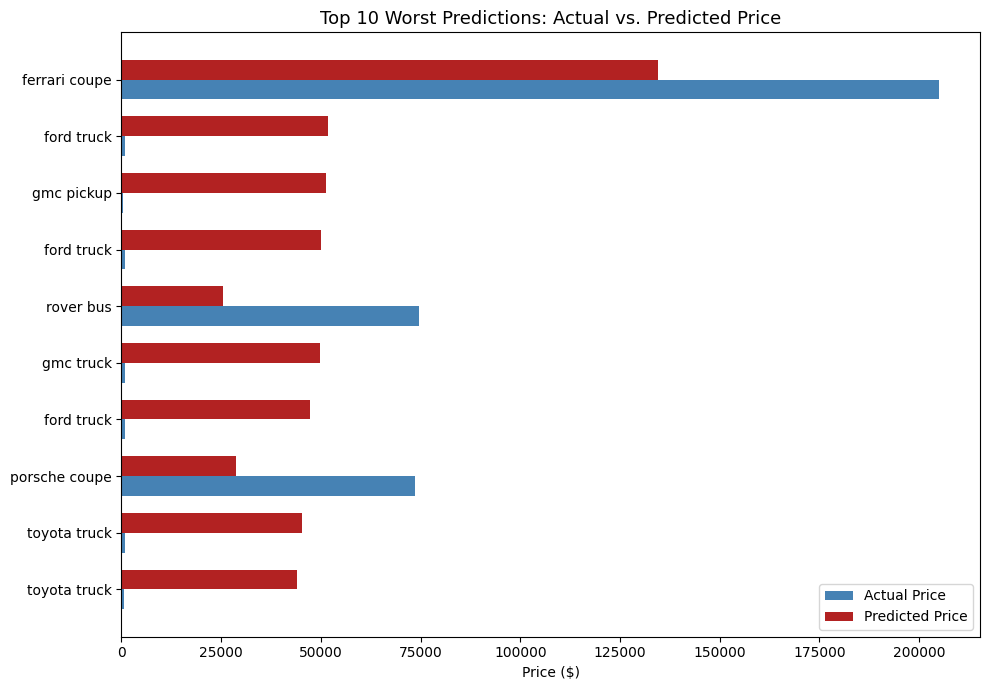

In [ ]:
#Top 10 Worst Predictions
#Build labels that identify each car (manufacturer + type) since row index alone isn't readable
worst_labeled = worst.copy()
worst_labeled['label'] = worst_labeled['manufacturer'] + ' ' + worst_labeled['type']

#Sort so the single worst miss is at the top of the chart, not the bottom
worst_labeled = worst_labeled.sort_values('abs_error', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

y_pos = np.arange(len(worst_labeled))
bar_height = 0.35

# Two bars per car: one for actual price, one for predicted price
ax.barh(y_pos - bar_height/2, worst_labeled['actual'], height=bar_height,
        label='Actual Price', color='steelblue')
ax.barh(y_pos + bar_height/2, worst_labeled['predicted'], height=bar_height,
        label='Predicted Price', color='firebrick')

ax.set_yticks(y_pos)
ax.set_yticklabels(worst_labeled['label'])
ax.set_xlabel('Price ($)')
ax.set_title('Top 10 Worst Predictions: Actual vs. Predicted Price', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

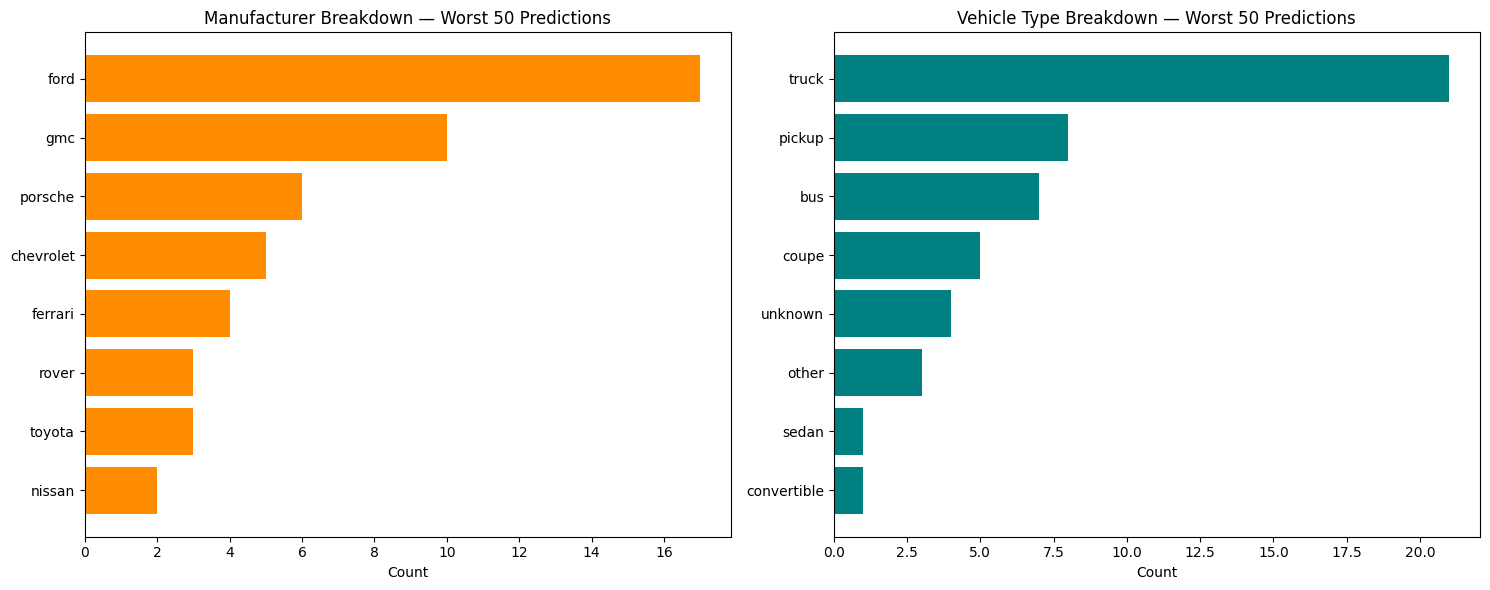

In [ ]:
#Worst Predictions by Manufacturer and Type
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Left panel: which manufacturers show up most among the worst predictions
manu_counts = worst_50['manufacturer'].value_counts()
axes[0].barh(manu_counts.index, manu_counts.values, color='darkorange')
axes[0].invert_yaxis()  # puts the most frequent manufacturer at the top, easier to scan
axes[0].set_title('Manufacturer Breakdown — Worst 50 Predictions', fontsize=12)
axes[0].set_xlabel('Count')

# Right panel: which vehicle types show up most among the worst predictions
type_counts = worst_50['type'].value_counts()
axes[1].barh(type_counts.index, type_counts.values, color='teal')
axes[1].invert_yaxis()
axes[1].set_title('Vehicle Type Breakdown — Worst 50 Predictions', fontsize=12)
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

**Notes on the Worst Predictions**

With Ram vehicles removed, the worst individual predictions reveal that the underlying data
quality issue was never unique to Ram — it shows up across multiple truck-heavy manufacturers,
alongside a separate, opposite pattern for rare luxury brands.

**1. Near-zero "placeholder" prices persist across Ford, GMC, and Chevrolet trucks.** Ford,
GMC, and Chevrolet trucks/pickups together account for roughly two-thirds of our worst 50
predictions. In several of our 10 worst individual misses, the pattern is identical to what we
originally saw with Ram: a truck's actual listed price is under \$1,100, while the model —
reasonably, based on year, mileage, and type — predicts \$50,000+. This confirms that removing
Ram alone did not fix the underlying issue: certain truck/pickup listings across several
manufacturers likely contain data entry errors, placeholder prices, or damaged/parts-only
vehicles that our cleaning steps didn't fully catch.

**2. Rare luxury vehicles (Aston-Martin, Ferrari, Porsche, Land Rover) are still
under-predicted.** This pattern is unchanged from before: these brands are rare in our 426K-row
dataset, so the model hasn't seen enough examples to learn their true price premium, and its
predictions default toward more typical price ranges for similar body styles.

**Practical takeaway:** removing Ram improved overall accuracy (best model RMSE dropped from
\$7,130 to \$6,988), but the real underlying issue — implausibly low listed prices on certain
truck listings — is broader than one manufacturer. Before relying on this model for
truck/pickup pricing, the dealership should spot-check listings with suspiciously low prices
across all manufacturers, not just Ram. Luxury and exotic vehicles should continue to be
priced manually rather than through this model.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

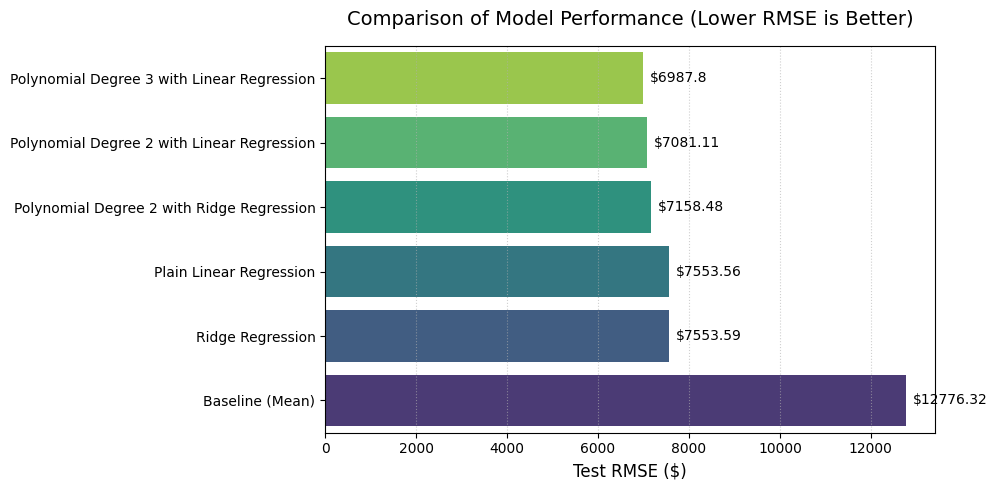

In [ ]:
#Dictionary storing the Test RMSE values you've gathered so far (Ram vehicles removed from dataset)
model_data = {
    'Model': [
        'Baseline (Mean)',
        'Plain Linear Regression',
        'Ridge Regression',
        'Polynomial Degree 2 with Linear Regression',
        'Polynomial Degree 2 with Ridge Regression',
        'Polynomial Degree 3 with Linear Regression'
    ],
    # RMSE from models
    'Test RMSE': [12776.32, 7553.56, 7553.59, 7081.11, 7158.48, 6987.80]  # updated: Ram vehicles removed
}

#Convert to a DataFrame and sort so the best model is at the top
df_models = pd.DataFrame(model_data).sort_values(by='Test RMSE', ascending=True)

#Plot the horizontal bar chart
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Test RMSE', y='Model', data=df_models, palette='viridis_r')

#Add the exact values onto the ends of the bars for quick reference
for container in ax.containers:
    ax.bar_label(container, fmt='$% s', padding=5)

#Labels and styling
plt.title('Comparison of Model Performance (Lower RMSE is Better)', fontsize=14, pad=15)
plt.xlabel('Test RMSE ($)', fontsize=12)
plt.ylabel('')
plt.grid(axis='x', linestyle=':', alpha=0.6)

#Automatically adjust spacing so text fits neatly
plt.tight_layout()
plt.show()

### Deployment

Now that we've settled on our best model and findings, it's time to deliver something the dealership can actually use. Below is a price estimator tool built on our best model (Degree-3 Polynomial + Linear Regression), along with an interactive version that walks a non-technical user through entering a car's details.


In [ ]:
def predict_car_price(year, manufacturer, vehicle_type, odometer, drive,
                       condition='good', fuel='gas', transmission='automatic',
                       title_status='clean', paint_color='white', state='ca'):
    """
    Takes plain-English car details and returns a predicted price using our best model.
    Warns the dealer if any category wasn't seen during training, since the model will
    silently treat unknown categories as "none of the above" rather than erroring out.
    """
    # --- Validation: warn if any category is unfamiliar to the model ---
    known_values = {
        'manufacturer': cars_clean['manufacturer'].unique(),
        'type': cars_clean['type'].unique(),
        'drive': cars_clean['drive'].dropna().unique(),
        'paint_color': cars_clean['paint_color'].unique(),
        'state': cars_clean['state'].unique(),
    }
    inputs_to_check = {'manufacturer': manufacturer, 'type': vehicle_type,
                        'drive': drive, 'paint_color': paint_color, 'state': state}

    for field, value in inputs_to_check.items():
        if value not in known_values[field]:
            print(f"⚠️ Warning: '{value}' wasn't in our training data for '{field}' — prediction may be unreliable.")

    # Step 1: build a single-row dataframe with the raw fields, same shape as our original data
    raw = pd.DataFrame([{
        'year': year, 'manufacturer': manufacturer, 'type': vehicle_type,
        'odometer': odometer, 'drive': drive, 'condition': condition,
        'fuel': fuel, 'transmission': transmission, 'title_status': title_status,
        'paint_color': paint_color, 'state': state,
    }])

    # Step 2: reapply the SAME manual mappings used during training (cells 33-40)
    raw['condition_ranked'] = raw['condition'].map(condition_map).fillna(2)
    raw['title_clean'] = raw['title_status'].map(title_map).fillna(0).astype(int)
    raw['transmission_automatic'] = raw['transmission'].map(transmission_map).fillna(0).astype(int)
    raw['fuel_gas'] = raw['fuel'].map(gas_map).fillna(0).astype(int)
    raw = raw.drop(columns=['condition', 'title_status', 'transmission', 'fuel'])

    # Step 3: one-hot encode using the SAME fitted encoder (ohe) from cell 43 —
    # pull the column order directly from the encoder itself, never hardcode it,
    # so this can't break again even if upstream cells change
    cat_cols_remaining = list(ohe.feature_names_in_)
    encoded_array = ohe.transform(raw[cat_cols_remaining])
    encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(cat_cols_remaining), index=raw.index)
    final_input = pd.concat([raw.drop(columns=cat_cols_remaining), encoded_df], axis=1)

    # Step 4: force column names/order to EXACTLY match X_train —
    # any dummy column the dealer's input doesn't touch gets filled with 0
    final_input = final_input.reindex(columns=X_train.columns, fill_value=0)

    # Step 5: predict using our best model (the degree-3 polynomial pipeline)
    predicted_price = pipe.predict(final_input)[0]
    return round(predicted_price, 2)


def price_estimator_tool():
    """
    Walks a dealer through simple prompts and returns a price estimate.
    No Python knowledge needed — just type answers when asked.
    """
    print("=== Used Car Price Estimator ===\n")

    year = int(input("Year (e.g. 2019): "))
    manufacturer = input("Manufacturer (e.g. toyota): ").strip().lower()
    vehicle_type = input("Vehicle type (e.g. sedan, suv, pickup): ").strip().lower()
    odometer = float(input("Odometer / mileage (e.g. 45000): "))
    drive = input("Drive type (fwd, rwd, 4wd): ").strip().lower()
    condition = input("Condition (new, like new, excellent, good, fair, salvage) [default: good]: ").strip().lower() or 'good'

    estimate = predict_car_price(
        year=year, manufacturer=manufacturer, vehicle_type=vehicle_type,
        odometer=odometer, drive=drive, condition=condition
    )

    print(f"\n💰 Estimated fair market price: ${estimate:,.2f}")
    return estimate

In [ ]:
def price_estimator_tool():
    """
    Walks a dealer through simple prompts and returns a price estimate.
    No Python knowledge needed — just type answers when asked.
    """
    print("=== Used Car Price Estimator ===\n")

    # input() pauses and waits for the person to type an answer, then hits Enter
    year = int(input("Year (e.g. 2019): "))
    manufacturer = input("Manufacturer (e.g. toyota): ").strip().lower()
    vehicle_type = input("Vehicle type (e.g. sedan, suv, pickup): ").strip().lower()
    odometer = float(input("Odometer / mileage (e.g. 45000): "))
    drive = input("Drive type (fwd, rwd, 4wd): ").strip().lower()
    condition = input("Condition (new, like new, excellent, good, fair, salvage) [default: good]: ").strip().lower() or 'good'

    estimate = predict_car_price(
        year=year, manufacturer=manufacturer, vehicle_type=vehicle_type,
        odometer=odometer, drive=drive, condition=condition
    )

    print(f"\n💰 Estimated fair market price: ${estimate:,.2f}")
    print("Manual data check and pricing should still be conducted to confirm the best price.")
    return estimate

# To run it, the dealer just calls:
# price_estimator_tool()

In [ ]:
#call the estimator to test
price_estimator_tool()

=== Used Car Price Estimator ===



KeyboardInterrupt: Interrupted by user

**Next Steps and Recommendations**

Based on our modeling results and the patterns found in our worst predictions, we recommend the following:

1. **Spot-check truck/pickup listings across all manufacturers for data errors**, not just Ram. Ford, GMC, and Chevrolet trucks now account for the majority of our worst 50 predictions, with the same near-\$0 placeholder-price pattern we originally found in Ram listings.
2. **Rely on manual appraisal for exotic/luxury vehicles** (Ferrari, Aston-Martin, Porsche, Land Rover), which are too rare in this dataset for the model to price reliably.
3. **Use the model as a screening tool, not a final price-setter.** With a typical error of roughly \$7,000, it's best used to flag cars priced well outside the expected range for their year, mileage, and type — final pricing should combine the model's estimate with human judgment.
4. **Expand training data over time**, especially for underrepresented vehicle types and manufacturers, to improve future accuracy.
5. **Consider adding features** not in this dataset — accident history, number of owners, regional demand — which likely explain some of the remaining prediction error.
6. **Re-evaluate whether removing entire manufacturers is the right long-term fix.** Removing Ram improved accuracy here, but our analysis suggests the real problem is bad *listings*, not bad *manufacturers*. A more targeted fix — filtering suspiciously low prices for trucks specifically, regardless of manufacturer — may preserve more usable data than removing brands wholesale.
